In [ ]:
Challenge ONE: Telecom X 2 - análisis de evasión de clientes
Ruben Vargas
	•	Problema: alta tasa de cancelación (Churn).
	•	Objetivo: Realizacion de modelos para analizar variables y dar recomendaciones.


In [3]:
#importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#carga del archivo e identificacion de anidacion
url= "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df_raw=pd.read_json(url)
df_raw.head()
df_raw.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [5]:
#normalizacion del archivo anidado
customer = pd.json_normalize(df_raw["customer"])
phone = pd.json_normalize(df_raw["phone"])
internet = pd.json_normalize(df_raw["internet"])
account = pd.json_normalize(df_raw["account"])
df_base = df_raw.drop(columns=["customer","phone","internet","account"])
df = pd.concat([df_base, customer, phone, internet, account], axis=1)
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
df = df.dropna()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [8]:
#EDA
df["Churn"] = df["Churn"].str.strip()
df["Churn"].value_counts()
df = df[df["Churn"] != ""]
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
No,0.734215
Yes,0.265785


In [9]:
#analisis por duracion de contrato
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887228
                Yes      0.112772
Two year        No       0.971513
                Yes      0.028487
Name: proportion, dtype: float64

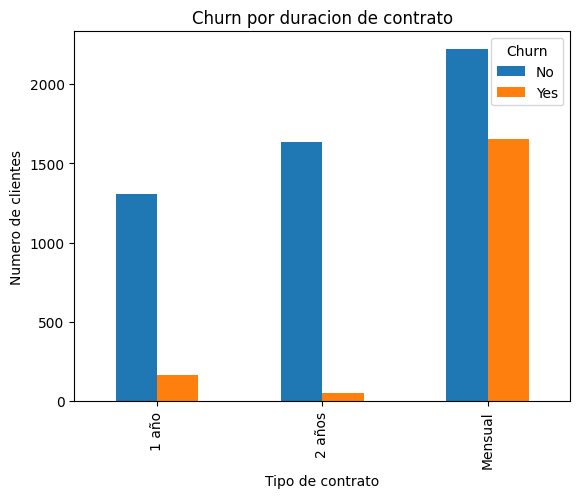

In [12]:
#visualizacion churn vs contrato
df["Contract"] = df["Contract"].replace({
    "Two year": "2 años",
    "One year": "1 año",
    "Month-to-month": "Mensual"
})
df.groupby("Contract")["Churn"].value_counts().unstack().plot(kind="bar")
plt.title("Churn por duracion de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Numero de clientes")
plt.show()

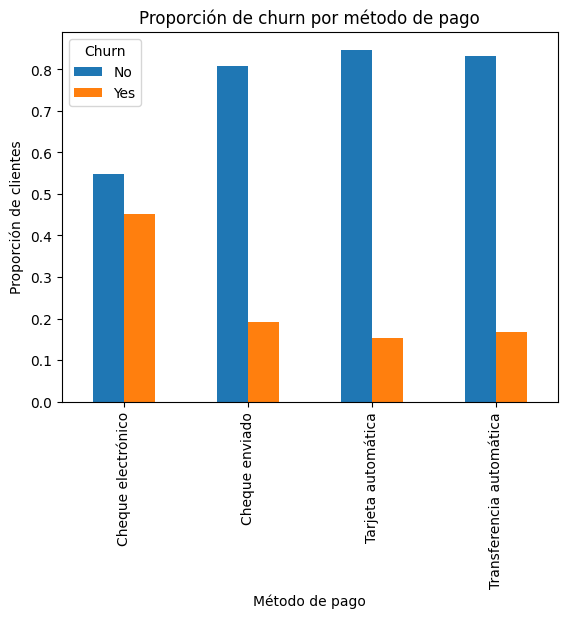

In [20]:
#visualizacion churn vs tipo de pago
df["PaymentMethod"] = df["PaymentMethod"].replace({
    "Electronic check": "Cheque electrónico",
    "Mailed check": "Cheque",
    "Bank transfer (automatic)": "Transferencia automática",
    "Credit card (automatic)": "Tarjeta de crédito"
})
df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar")

plt.title("Proporción de churn por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Proporción de clientes")

plt.show()

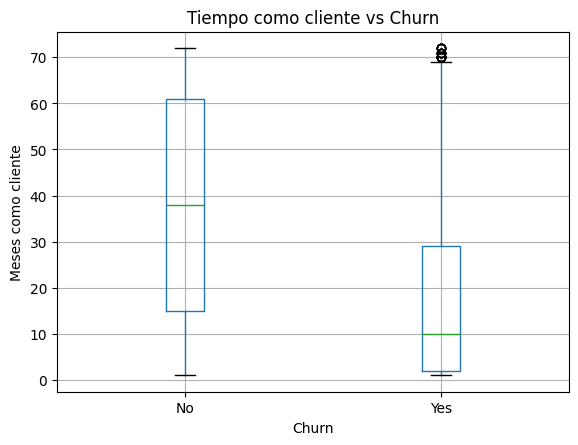

In [21]:
#visualizacion churn vs tiempo como cliente
df.boxplot(column="tenure", by="Churn")

plt.title("Tiempo como cliente vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")

plt.show()

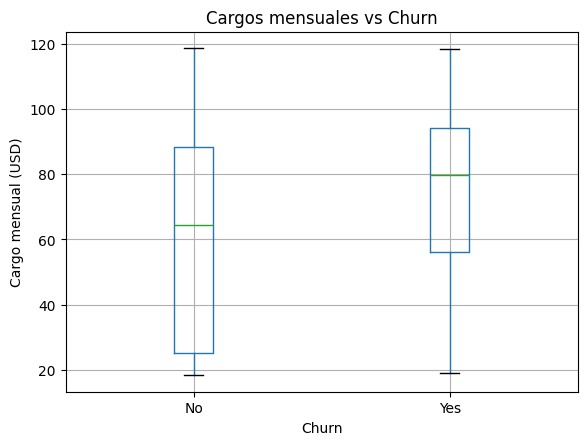

In [23]:
#visualizacion churn vs cargo mensual
df.boxplot(column="Charges.Monthly", by="Churn")

plt.title("Cargos mensuales vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual (USD)")

plt.show()

**Conclusiones**

El análisis exploratorio del dataset permitió identificar varios factores asociados con la cancelación del servicio citado a continuacion:


1. **Tipo de contrato**

Los clientes con contratos mensuales presentan la mayor tasa de cancelación frente a los contratos de uno o dos años, lo que sugiere incentivar contratos de mayor duración para favorecen la retención de los clientes.

2. **Método de pago**

El cheque electrónico como metodo de pago presenta una proporción significativamente mayor de cancelación en comparación con los otros metodos.

3. **Antigüedad del cliente**

Los clientes con menor tiempo en la empresa tienden a cancelar con mayor frecuencia.

4. **Cargos mensuales**

Los clientes que tienen cargos mensuales más elevados tienden a cancelar con mayor frecuencia, lo que sugiere que el costo del servicio puede influir en la decisión de abandono.

**Recomendaciones**

A partir del análisis realizado se sugieren las siguientes acciones para reducir la tasa de churn:

	•	Incentivar contratos de mayor duración, ya que presentan menor tasa de cancelación.
	•	Promover métodos de pago automáticos para mejorar la retención de clientes.
	•	Implementar estrategias de retención para clientes nuevos, especialmente durante los primeros meses.
	•	Evaluar la estructura de precios y paquetes de servicio para clientes con cargos mensuales elevados.

In [42]:
import pandas as pd

df = pd.read_csv("telecomx_cleaned.csv")

In [44]:
#
df["Churn"] = df["Churn"].replace({"No":0, "Yes":1})

/tmp/ipykernel_382/142656858.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"No":0, "Yes":1})


In [45]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [47]:
#
df = pd.get_dummies(df, drop_first=True)


(7032, 7062)

In [48]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
0,5163
1,1869


In [49]:
#Train/Test split (con estratificación)
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5625, 7061), (1407, 7061))

In [51]:
#Modelo 1: Regresión Logística
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)
proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [52]:
#Modelo 2: random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)
proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [54]:
#Metricas
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

def evaluar_modelo(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

resumen = pd.DataFrame([
    evaluar_modelo("Regresión Logística", y_test, pred_log),
    evaluar_modelo("Random Forest", y_test, pred_rf),
])

resumen

print("=== Regresión Logística ===")
print(classification_report(y_test, pred_log))
print("Matriz de confusión:\n", confusion_matrix(y_test, pred_log))

print("\n=== Random Forest ===")
print(classification_report(y_test, pred_rf))
print("Matriz de confusión:\n", confusion_matrix(y_test, pred_rf))

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.79      0.97      0.87      1033
           1       0.75      0.28      0.41       374

    accuracy                           0.78      1407
   macro avg       0.77      0.62      0.64      1407
weighted avg       0.78      0.78      0.75      1407

Matriz de confusión:
 [[998  35]
 [268 106]]

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407

Matriz de confusión:
 [[948  85]
 [208 166]]


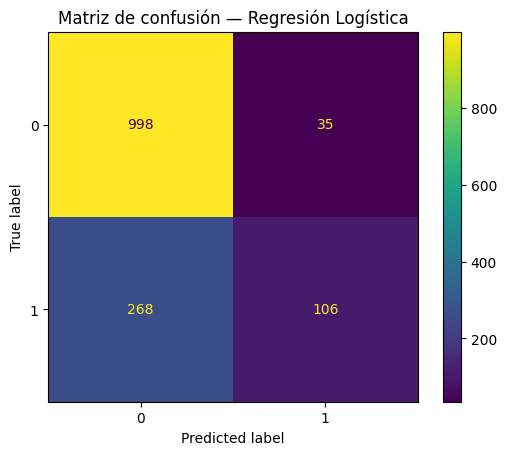

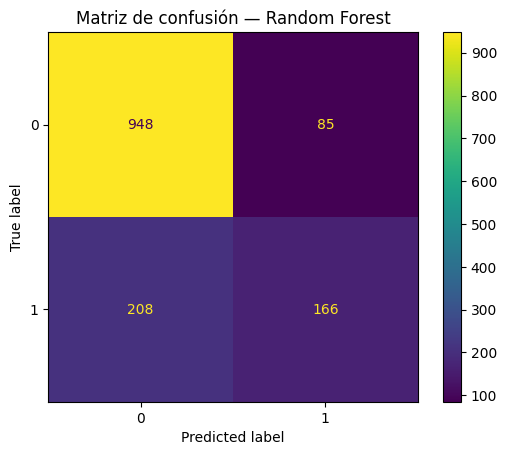

In [55]:
#Visualización de matrices de confusión
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, pred_log, ax=ax)
plt.title("Matriz de confusión — Regresión Logística")
plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax)
plt.title("Matriz de confusión — Random Forest")
plt.show()

AUC Logística: 0.8352185369439513
AUC Random Forest: 0.8392784113557419


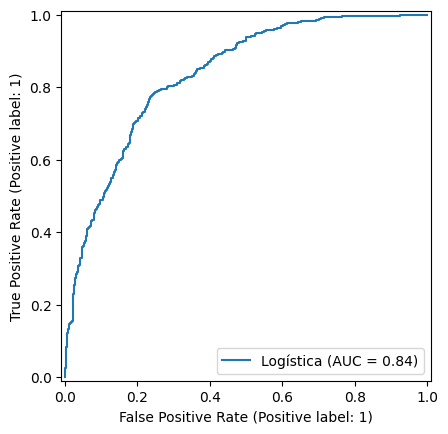

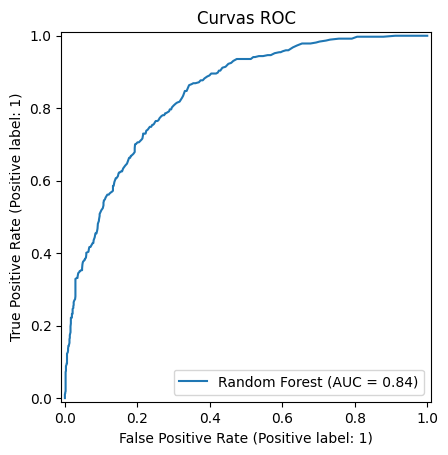

In [56]:
#ROC-AUC
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("AUC Logística:", roc_auc_score(y_test, proba_log))
print("AUC Random Forest:", roc_auc_score(y_test, proba_rf))

RocCurveDisplay.from_predictions(y_test, proba_log, name="Logística")
RocCurveDisplay.from_predictions(y_test, proba_rf, name="Random Forest")
plt.title("Curvas ROC")
plt.show()

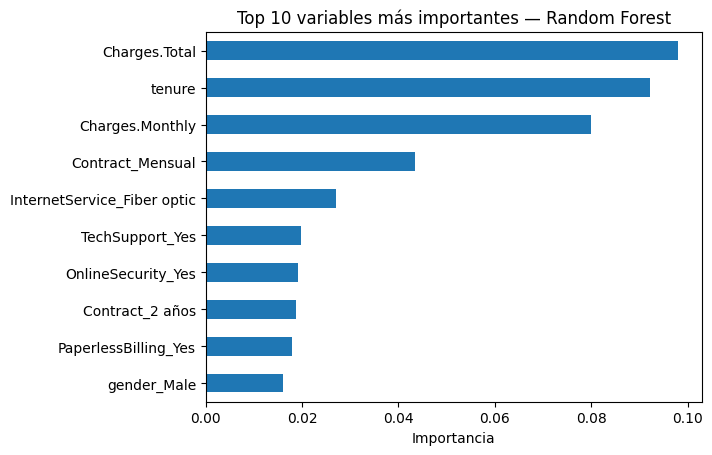

In [57]:
import numpy as np

importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importancias.sort_values(ascending=False).head(10)
top10
top10.sort_values().plot(kind="barh")
plt.title("Top 10 variables más importantes — Random Forest")
plt.xlabel("Importancia")
plt.show()

**Interpretación de resultados**

-Distribución de cancelación de clientes:
El análisis inicial muestra que la mayoría de los clientes no cancelan el servicio, mientras que una proporción menor corresponde a clientes que sí cancelaron. Sin embargo, el número de cancelaciones sigue siendo significativo con un porcentaje del 26.6% lo que se acerca a que 1 de cada 4 clientes cancela, lo que indica que la empresa enfrenta un problema relevante de retención de clientes dado que adquirir nuevos clientes suele ser más costoso que retener los existentes.

-Relación entre tipo de contrato y cancelación:
El análisis muestra una relación clara entre el tipo de contrato y la cancelación del servicio.
Los clientes con contrato mensual presentan una tasa de cancelación considerablemente mayor en comparación con aquellos que tienen contratos de uno o dos años.

-Método de pago y cancelación:
El análisis por método de pago revela que los clientes que utilizan cheque electrónico presentan una mayor proporción de cancelación en comparación con otros métodos de pago.
En contraste, los métodos automáticos como transferencia bancaria automática o tarjeta de crédito automática presentan tasas de cancelación más bajas.

-Tiempo como cliente:
El análisis de la variable meses como cliente muestra una diferencia clara entre clientes que cancelan y los que permanecen.
Los clientes que cancelan tienden a tener menos tiempo en la empresa, mientras que los clientes que permanecen suelen tener una antigüedad mayor.
Esto sugiere que el riesgo de cancelación es mayor durante los primeros meses del servicio.

-Cargos mensuales y cancelación:
Los clientes que cancelan el servicio tienden a presentar cargos mensuales más altos en comparación con los clientes que permanecen.

Esto podría indicar que los clientes con planes más costosos pueden ser más sensibles al precio o tener mayores expectativas sobre el servicio.


**Importancia de variables según Random Forest**

El modelo Random Forest permitió identificar y confirmar las variables más relevantes para predecir la cancelación de clientes. Además de identificar estas variables importantes, el desempeño del modelo fue evaluado mediante la métrica AUC con un valor de aproximadamente 0.84, lo que indica una buena capacidad del modelo para distinguir entre clientes que cancelarán el servicio y aquellos que permanecerán.

**Conclusiones del análisis**

A partir del análisis exploratorio y del modelado predictivo se identificaron varios factores asociados a la cancelación de clientes.

Los principales factores que influyen en el churn son clientes:

	•	con cargos mensuales más altos
	•	con menor tiempo en la empresa
	•	con contratos mensuales
	•	que utilizan cheque electrónico como método de pago
	•	que no cuentan con servicios adicionales como soporte técnico o seguridad en línea

El modelo Random Forest mostró el mejor desempeño para predecir la cancelación de clientes, con un mejor equilibrio entre precisión y recall en comparación con la regresión logística.

**Recomendaciones para la empresa**

A partir de los resultados del análisis, la empresa podría implementar las siguientes estrategias para reducir la cancelación de clientes.

-Programas de fidelización temprana:
Dado que los clientes nuevos presentan mayor riesgo de cancelación, la empresa podría implementar programas de bienvenida, descuentos iniciales o beneficios durante los primeros meses.

-Incentivar contratos de largo plazo:
Promover contratos de uno o dos años mediante descuentos o beneficios adicionales podría ayudar a reducir la tasa de cancelación.

-Promoción de servicios adicionales:
Los clientes que cuentan con servicios como soporte técnico y seguridad en línea presentan menor probabilidad de cancelar el servicio. Promover estos servicios podría aumentar la fidelización.

-Revisar la estructura de precios:
Los cargos mensuales elevados parecen estar asociados a mayor churn. La empresa podría analizar si existen planes o combinaciones de servicios que permitan ofrecer mayor valor percibido por parte del cliente.

**Conclusión final del proyecto**

Este análisis demuestra cómo el uso de técnicas de análisis de datos y machine learning permite identificar patrones de comportamiento de los clientes y anticipar posibles cancelaciones.

La implementación de modelos predictivos como Random Forest puede ayudar a la empresa a identificar clientes con alto riesgo de churn y aplicar estrategias de retención de manera proactiva, lo que puede contribuir a mejorar la estabilidad de la base de clientes y aumentar la rentabilidad del negocio.
